# 实验二：纯 PyTorch 手写 Logistic 回归

在本实验中，我们**不使用任何高级 API**（如 `nn.Linear`、`nn.BCELoss`、`torch.optim` 等），
而是完全基于 PyTorch 的张量操作，手动实现 Logistic 回归模型，包括：

- 参数初始化（权重 $W$ 和偏置 $b$）
- 前向传播（Sigmoid 激活）
- 损失函数（二元交叉熵 BCE Loss）
- 手动计算梯度并更新参数（梯度下降）

通过本实验，你将深入理解神经网络训练的底层机制，而不是依赖框架的封装。

## 1. 导入依赖

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 固定随机种子以便复现
torch.manual_seed(42)
np.random.seed(42)

## 2. 生成二分类数据集

我们生成两组高斯分布的二维数据，分别对应两个类别（标签 0 和 1）。

X shape: torch.Size([200, 2]), y shape: torch.Size([200, 1])


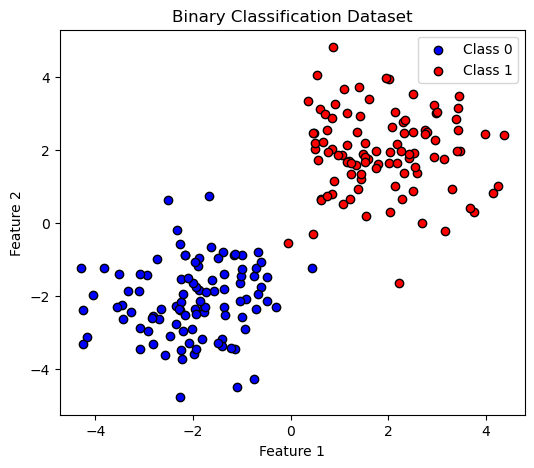

In [13]:
# 每类 100 个样本
N = 100
torch.manual_seed(10)

# 类别 0：均值在 (-2, -2)
X0 = torch.randn(N, 2) - 2
# 类别 1：均值在 (2, 2)
X1 = torch.randn(N, 2) + 2

# 拼接数据和标签
X = torch.cat([X0, X1], dim=0)                       # shape: (200, 2)
y = torch.cat([torch.zeros(N), torch.ones(N)])        # shape: (200,)
y = y.reshape(-1, 1)                                   # shape: (200, 1)

print(f'X shape: {X.shape}, y shape: {y.shape}')
# Visualize the dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:N, 0].numpy(), X[:N, 1].numpy(), c='blue', label='Class 0', edgecolors='k')
plt.scatter(X[N:, 0].numpy(), X[N:, 1].numpy(), c='red', label='Class 1', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend()
plt.show()


## 3. 手动定义模型参数

Logistic 回归模型的参数为权重向量 $W$（形状 `[2, 1]`）和偏置 $b$（形状 `[1, 1]`）。
这里我们不使用 `nn.Linear`，而是自己维护参数张量，这样可以直接观察每个参数如何参与前向传播、反向传播和梯度更新。

### 这一部分需要你想清楚什么？

- 为什么输入是二维特征时，权重应该有 2 行而不是 1 行或 200 行？
- 为什么二分类只需要输出一个 logit，因此权重的列数是 1？
- 为什么偏置通常写成可以与批量样本广播相加的形状，而不是一个 Python 标量？
- 为什么 `requires_grad=True` 必须加在可学习参数上？如果漏掉，会发生什么？

### 你可以这样检查自己的实现

- `X` 的形状是 `(200, 2)`，因此每个样本有 2 个输入特征。
- 若 `X @ W` 要得到 `(200, 1)` 的输出，那么 `W` 应满足什么形状？
- `b` 需要能加到 `(200, 1)` 上，因此它的形状至少应当与单个输出维度兼容。
- 打印参数时，应看到 `W` 和 `b` 都是可求梯度张量。

下面的代码单元只保留参数创建与打印，具体初始化请你在练习区中完成。

In [ ]:
# 手动初始化参数
# 权重：输入维度 2，输出维度 1
### START CODE HERE ###

### END CODE HERE ###

# 偏置
### START CODE HERE ###

### END CODE HERE ###

print('初始化权重 W:', W.T)
print('初始化偏置 b:', b)

初始化权重 W: tensor([[-0.0990, -1.6662]], grad_fn=<PermuteBackward0>)
初始化偏置 b: tensor([[0.]], requires_grad=True)


## 4. 定义前向传播、损失函数与参数更新

### 4.1 前向传播（Forward Pass）

Logistic 回归的前向传播满足：

$$z = X W + b, \quad \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

这里的关键不是背公式，而是把张量形状和计算顺序想清楚。`X` 是一个批量样本矩阵，`W` 是参数矩阵，`b` 是输出维度上的偏置。先做线性变换，再做 Sigmoid，才能把 logit 映射到 $(0, 1)$ 的概率区间。

### 4.2 损失函数（Binary Cross-Entropy Loss）

$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

因为这里输出的是概率，所以标签 `y` 必须与 `y_hat` 形状兼容。若概率恰好等于 0 或 1，直接取对数会导致数值问题，因此通常要先做裁剪。

### 4.3 这一部分的思考提示

- `sigmoid` 这个函数应该接收线性输出 `z`，还是已经是概率的 `y_hat`？
- 为什么 `forward` 中的矩阵乘法写法必须保证 batch 维保留在第 0 维？
- 为什么 BCE 损失最后要得到一个标量，而不是保留每个样本的损失向量？
- 为什么这里先手动实现 `bce_loss`，而不是直接调用高级 API？

### 4.4 自查问题清单

- `forward(X, W, b)` 的返回值形状是否为 `(样本数, 1)`？
- Sigmoid 输出是否落在 0 到 1 之间？
- `bce_loss(y_hat, y)` 是否返回单个标量张量？
- 你的实现里是否考虑了 `log(0)` 的数值稳定性？

注意：下面的代码单元要你补全三个最核心的函数。请只在 `### START CODE HERE ###` 与 `### END CODE HERE ###` 之间填写，不要修改打印语句。

In [ ]:
def sigmoid(z):
    """Sigmoid 激活函数"""
    ### START CODE HERE ###
    
    ### END CODE HERE ###

def forward(X, W, b):
    """前向传播：线性变换 + Sigmoid"""
    ### START CODE HERE ###
    
    ### END CODE HERE ###
    return y_hat

def bce_loss(y_hat, y):
    """手动实现二元交叉熵损失"""
    ### START CODE HERE ###
    # 防止 log(0) 的数值不稳定，先把预测概率限制在安全区间内
    
    ### END CODE HERE ###
    return loss

print('前向传播和损失函数定义完毕')

前向传播和损失函数定义完毕


## 5. 训练循环

这一部分是本实验最重要的练习区：你要把“前向传播 -> 计算损失 -> 反向传播 -> 手动更新参数 -> 清零梯度”这个完整闭环真正串起来。

### 为什么顺序不能乱？

- 只有先得到预测值，才能基于预测和标签计算损失。
- 只有损失是当前参数参与计算图得到的结果，`loss.backward()` 才能把梯度传回 `W.grad` 和 `b.grad`。
- 参数更新这一步不应该继续被 autograd 跟踪，因此要放在 `torch.no_grad()` 作用域里。
- PyTorch 的梯度默认会累积；如果不手动清零，下一轮会把旧梯度也算进去。

### 手动梯度下降时要特别注意

- 更新参数时使用的是参数当前保存的梯度，而不是再次手算导数。
- `learning_rate` 的作用是控制步长，过大可能震荡，过小可能下降很慢。
- `loss.item()` 适合做记录和打印，但不能替代用于反向传播的 `loss` 张量本身。
- 清零梯度通常放在一次参数更新之后或下一轮反向传播之前；关键是不要让上一轮梯度残留。

### 你可以用这些问题推导代码

- 本轮要先调用哪个函数得到 `y_hat`？
- 损失函数接收的两个输入分别是谁？
- 哪一行负责自动计算梯度？
- 哪几行属于“真正修改参数值”的步骤？
- 为什么 `W.grad.zero_()` 和 `b.grad.zero_()` 不能漏掉？

### 自查标准

- `losses` 中记录的是 Python 数值而不是张量对象。
- 打印的损失应该整体下降，而不是随机波动后持续发散。
- 训练结束后断言 `losses[-1] < losses[0]` 应能通过。
- 如果报错提示某个梯度是 `None`，通常说明参数没有正确参与计算图或初始化时忘记开启梯度。

In [ ]:
learning_rate = 0.1
num_epochs = 200
losses = []

for epoch in range(num_epochs):
    ### START CODE HERE ###
    # 1. 前向传播：根据当前参数得到预测概率
    

    # 2. 计算损失，并把数值记录到 losses
    

    # 3. 反向传播：自动计算 W 和 b 的梯度
    

    # 4. 手动更新参数（注意不要让 autograd 跟踪这一步）
    

    # 5. 手动清零梯度，避免下一轮梯度累积
    
    ### END CODE HERE ###

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {loss.item():.4f}')

# 简单验证：损失应下降
assert losses[-1] < losses[0], '损失未下降，请检查代码！'
print('\n训练完成！损失从 {:.4f} 下降到 {:.4f}'.format(losses[0], losses[-1]))

Epoch [ 20/200]  Loss: 0.1429
Epoch [ 40/200]  Loss: 0.0726
Epoch [ 60/200]  Loss: 0.0529
Epoch [ 80/200]  Loss: 0.0433
Epoch [100/200]  Loss: 0.0375
Epoch [120/200]  Loss: 0.0337
Epoch [140/200]  Loss: 0.0309
Epoch [160/200]  Loss: 0.0287
Epoch [180/200]  Loss: 0.0270
Epoch [200/200]  Loss: 0.0256

训练完成！损失从 3.6705 下降到 0.0256


## 6. 可视化训练损失

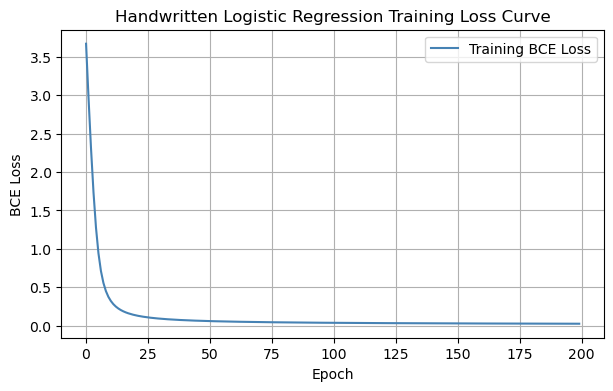

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(losses, color='steelblue', label='Training BCE Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Handwritten Logistic Regression Training Loss Curve')
plt.grid(True)
plt.legend()
plt.show()

## 7. 可视化决策边界

训练完成后，我们绘制模型的决策边界（$P(y=1|x) = 0.5$ 即 $z = 0$ 的等值线），并用不同颜色区分两类数据点。

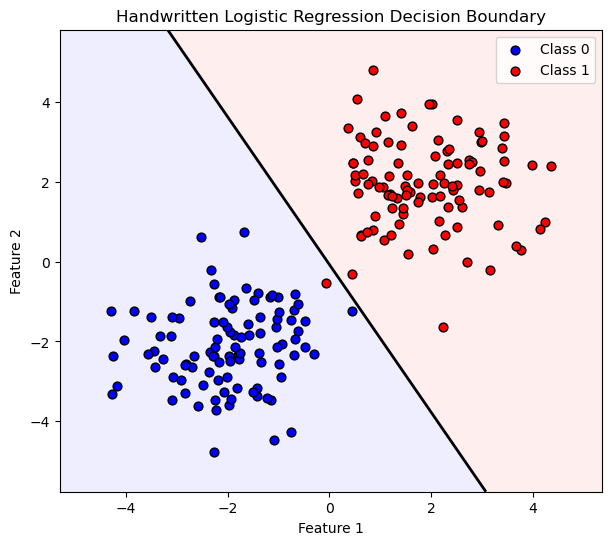

In [18]:
def plot_decision_boundary_manual(W, b, X, y, title='决策边界'):
    X_np = X.numpy()
    y_np = y.numpy().flatten()

    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = forward(grid, W, b).numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['#AAAAFF', '#FFAAAA'])
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1],
                c='blue', label='Class 0', edgecolors='k', s=40)
    plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1],
                c='red', label='Class 1', edgecolors='k', s=40)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary_manual(W, b, X, y, title='Handwritten Logistic Regression Decision Boundary')

## 8. 评估模型准确率

In [19]:
with torch.no_grad():
    y_hat_final = forward(X, W, b)           # 预测概率
    y_pred = (y_hat_final >= 0.5).float()    # 二值化
    accuracy = (y_pred == y).float().mean().item()

print(f'训练集准确率: {accuracy * 100:.2f}%')
print(f'学习到的权重 W: {W.detach().T}')
print(f'学习到的偏置 b: {b.detach()}')

训练集准确率: 99.50%
学习到的权重 W: tensor([[1.8380, 0.9932]])
学习到的偏置 b: tensor([[0.0687]])
